# Optimal Adjustment Policy

What is a hitter's situational swing change actually worth in runs? This notebook prices it as a
counterfactual: xRV of the swing he made, minus xRV of the swing the same hitter would have made
on the same pitch with count, base state, and platoon matchup held at his own unit mean. Pitch
type stays a control and is never de-situated — a hitter does not choose the pitch.

Two things separate this from the matched contrasts in `adjustability_results.ipynb`. It is defined
on every competitive swing rather than only on swings that land in a populated two-sided cell, and
the reference is the hitter himself, so nobody is scored against a league average he has no
business being compared to.

Source: `data/optimal_policy.parquet` (471 (batter, stand) units, 2024-25, min 400 swings), built by
`src/optimal_policy.py`. Validation report: `results/optimal_policy.md`.

In [1]:
# Setup: paths + the shared white-background fivethirtyeight theme used by the other results
# notebooks. Figures land in results/plots/adjustability/ alongside the R leaderboards.
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'data').exists())
DATA = ROOT / 'data'
PLOTS = ROOT / 'results' / 'plots'

# fivethirtyeight on white (grid color set explicitly; FT's default grid is white and vanishes).
FT = ['fivethirtyeight', {'figure.facecolor': 'white', 'axes.facecolor': 'white',
                          'savefig.facecolor': 'white', 'grid.color': '#cbcbcb'}]


def plot_path(name):
    """Route a figure filename to its results/plots/<category> subfolder."""
    sub = ('adjustability' if (name.startswith('adjustability') or name.startswith('adj_'))
           else 'repertoire' if name.startswith('repertoire')
           else 'predictiveness')
    d = PLOTS / sub
    d.mkdir(parents=True, exist_ok=True)
    return d / name


df = pd.read_parquet(DATA / 'optimal_policy.parquet')
judge = df[df['label'] == 'Aaron Judge'].iloc[0]
arraez = df[df['label'] == 'Luis Arraez'].iloc[0]

print(f'{len(df)} units loaded')
AXES = ['runs_total', 'runs_count', 'runs_gamestate', 'runs_platoon',
        'runs_interaction', 'runs_total_2k', 'runs_per_swing']
print(df[AXES].describe().loc[['mean', '50%', 'std', 'min', 'max']].round(4).to_string())

471 units loaded
      runs_total  runs_count  runs_gamestate  runs_platoon  runs_interaction  runs_total_2k  runs_per_swing
mean      1.5830      1.5469         -0.0324        0.0540            0.0145        -0.0283          0.0025
50%       1.2621      1.2233         -0.0239        0.0146            0.0210        -0.0532          0.0023
std       1.4048      1.3538          0.2012        0.2742            0.2561         0.6061          0.0018
min      -1.6752     -1.1920         -0.9202       -1.6260           -1.2319        -2.6312         -0.0020
max       7.3151      7.7748          0.6080        1.2139            1.1549         2.5788          0.0101


## Distribution

`runs_total` needs no artificial centring. With the counterfactual defined per hitter, a hitter
whose swing does not move with the situation scores near zero by construction. The realized
distribution sits slightly positive (mean +1.58, median +1.26) with a long right tail.

**Read it as a counting stat.** `runs_total` sums a per-swing delta across a season, so playing time
is baked in: `corr(runs_count, n_swings) = +0.62`. Most of the leaderboard spread below is volume,
not skill. The rate version already in the parquet, `runs_per_swing`, is nearly orthogonal to volume
(r = +0.10) and tracks mechanical adjustability substantially better —
`corr(runs_per_swing, adj_count) = +0.45` against +0.30 for the counting version. The counting stat
stays the headline because it is the season-value number, but every "who benefits" question below
is asked on the rate.

runs_total      corr(n_swings)=+0.626   corr(adj_count)=+0.288
runs_count      corr(n_swings)=+0.621   corr(adj_count)=+0.298
runs_per_swing  corr(n_swings)=+0.096   corr(adj_count)=+0.446


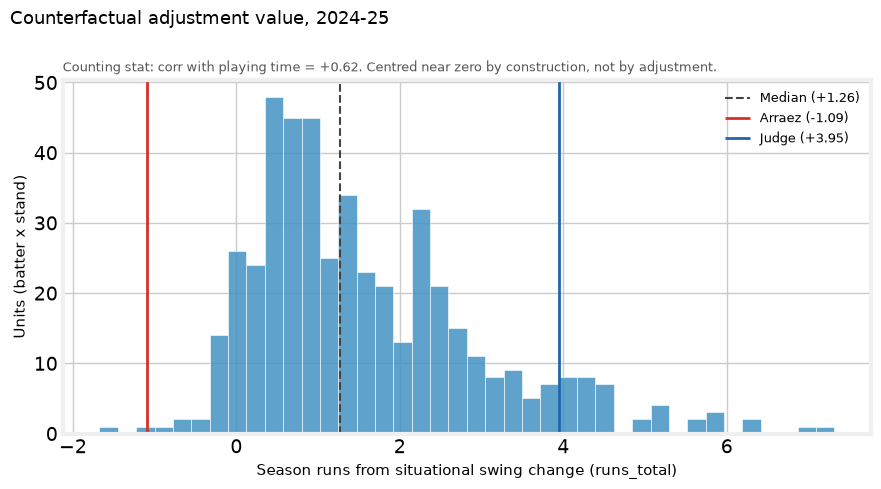

In [2]:
# Headline distribution, plus the volume confound stated in numbers rather than asserted.
for col in ['runs_total', 'runs_count', 'runs_per_swing']:
    r_vol = df[col].corr(df['n_swings'])
    r_adj = df[col].corr(df['adj_count'])
    print(f'{col:<15} corr(n_swings)={r_vol:+.3f}   corr(adj_count)={r_adj:+.3f}')

med = df['runs_total'].median()

with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(df['runs_total'], bins=40, color='#4393c3', edgecolor='white', alpha=0.85)
    ax.axvline(med, color='#444', lw=1.5, ls='--', label=f'Median ({med:+.2f})')
    ax.axvline(arraez['runs_total'], color='#d73027', lw=2,
               label=f"Arraez ({arraez['runs_total']:+.2f})")
    ax.axvline(judge['runs_total'], color='#2166ac', lw=2,
               label=f"Judge ({judge['runs_total']:+.2f})")
    ax.set_xlabel('Season runs from situational swing change (runs_total)', fontsize=11)
    ax.set_ylabel('Units (batter x stand)', fontsize=11)
    ax.set_title('Counting stat: corr with playing time = +0.62. Centred near zero by '
                 'construction, not by adjustment.',
                 fontsize=9, color='#555', loc='left')
    fig.suptitle('Counterfactual adjustment value, 2024-25', fontsize=13, x=0.02, ha='left')
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    fig.savefig(plot_path('adj_policy_season_dist.png'), dpi=150, bbox_inches='tight')
    plt.show()

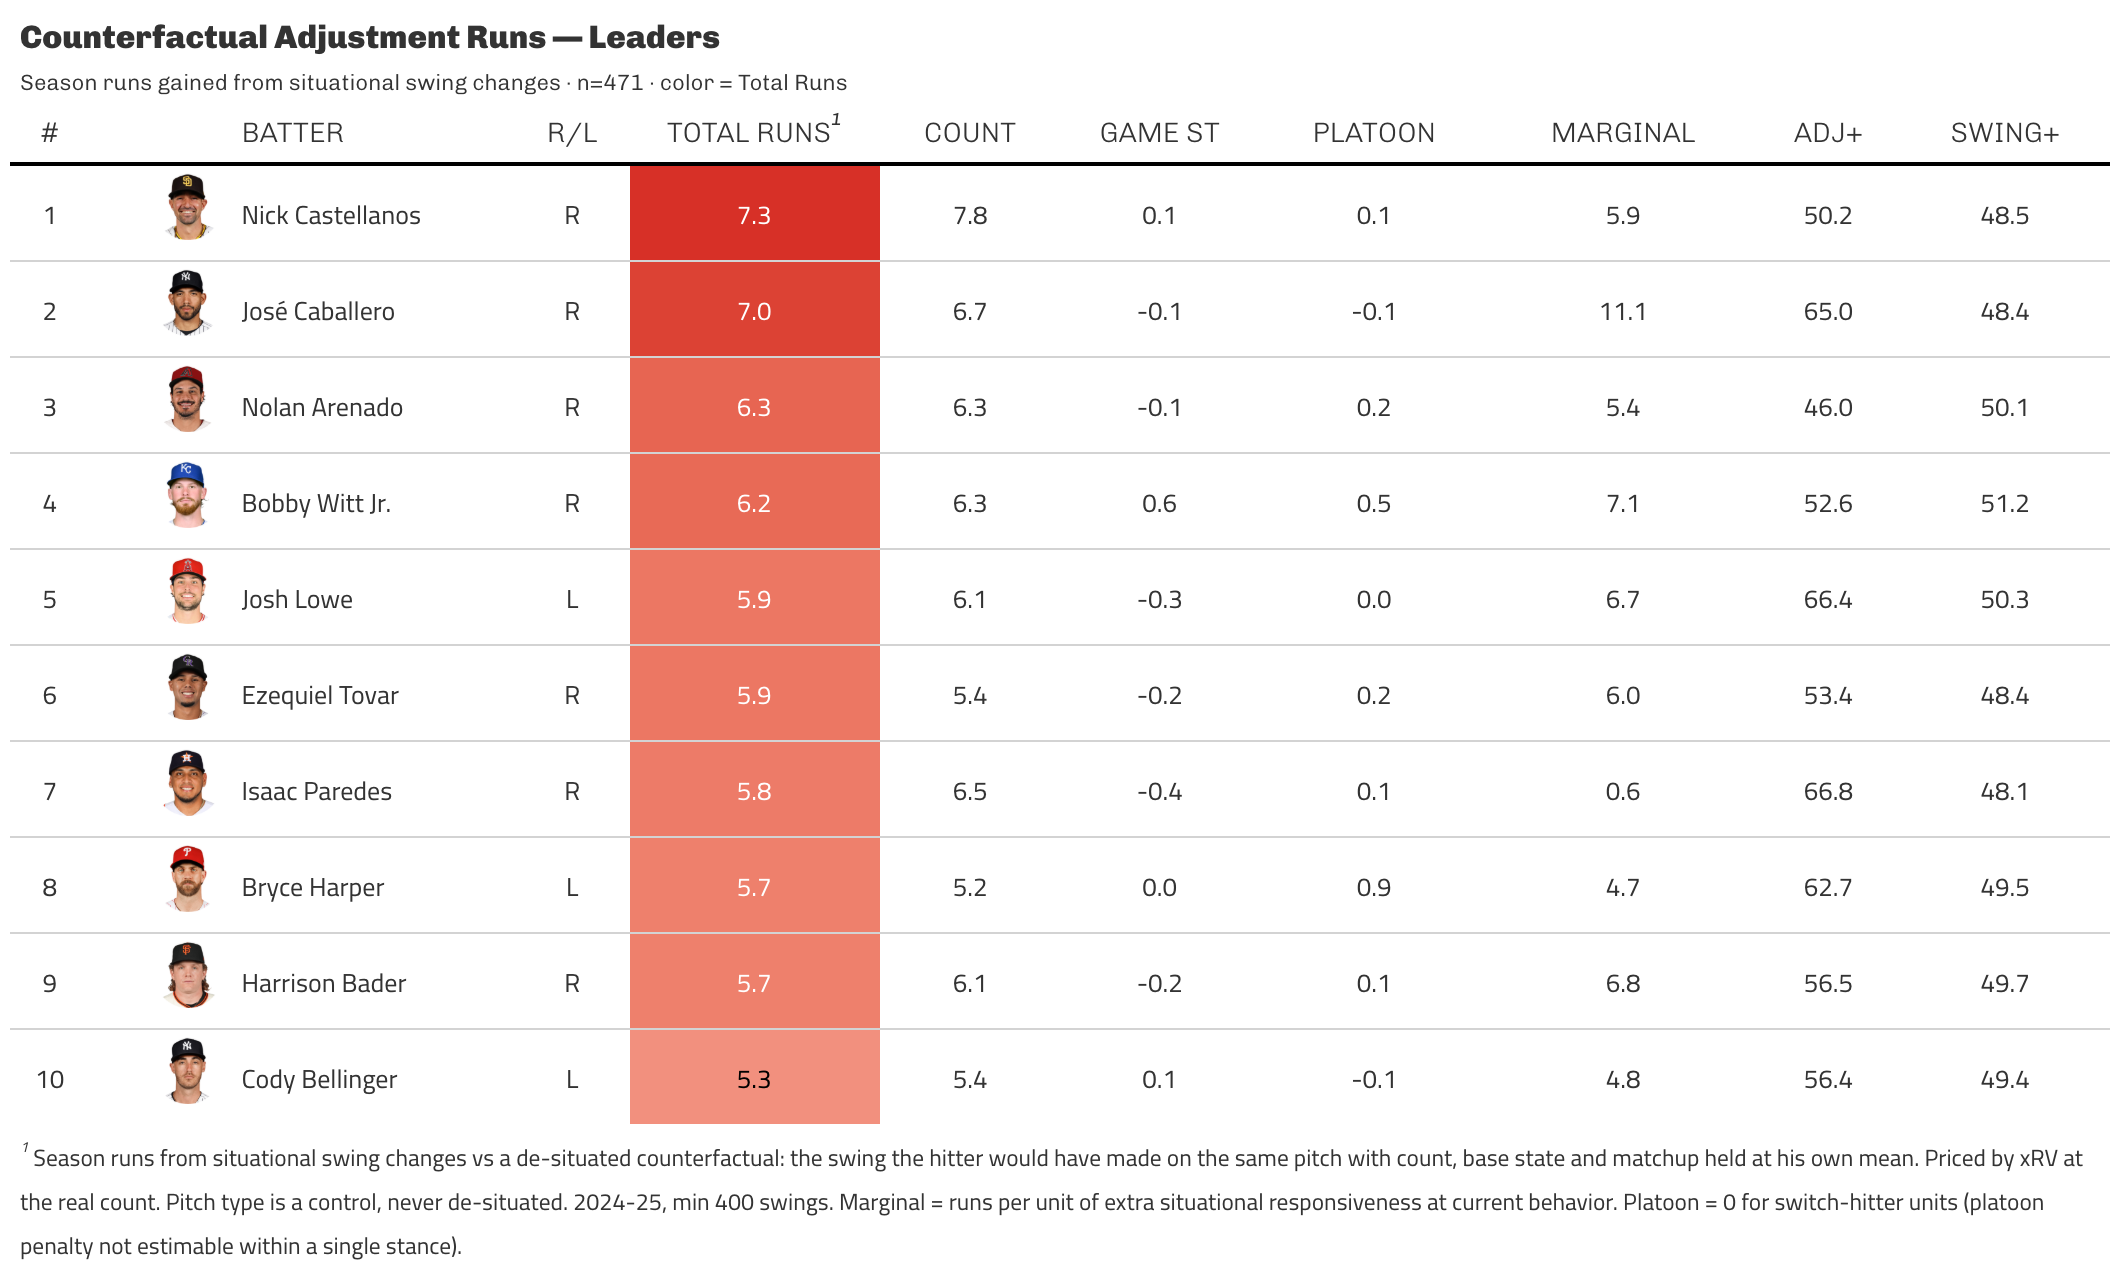

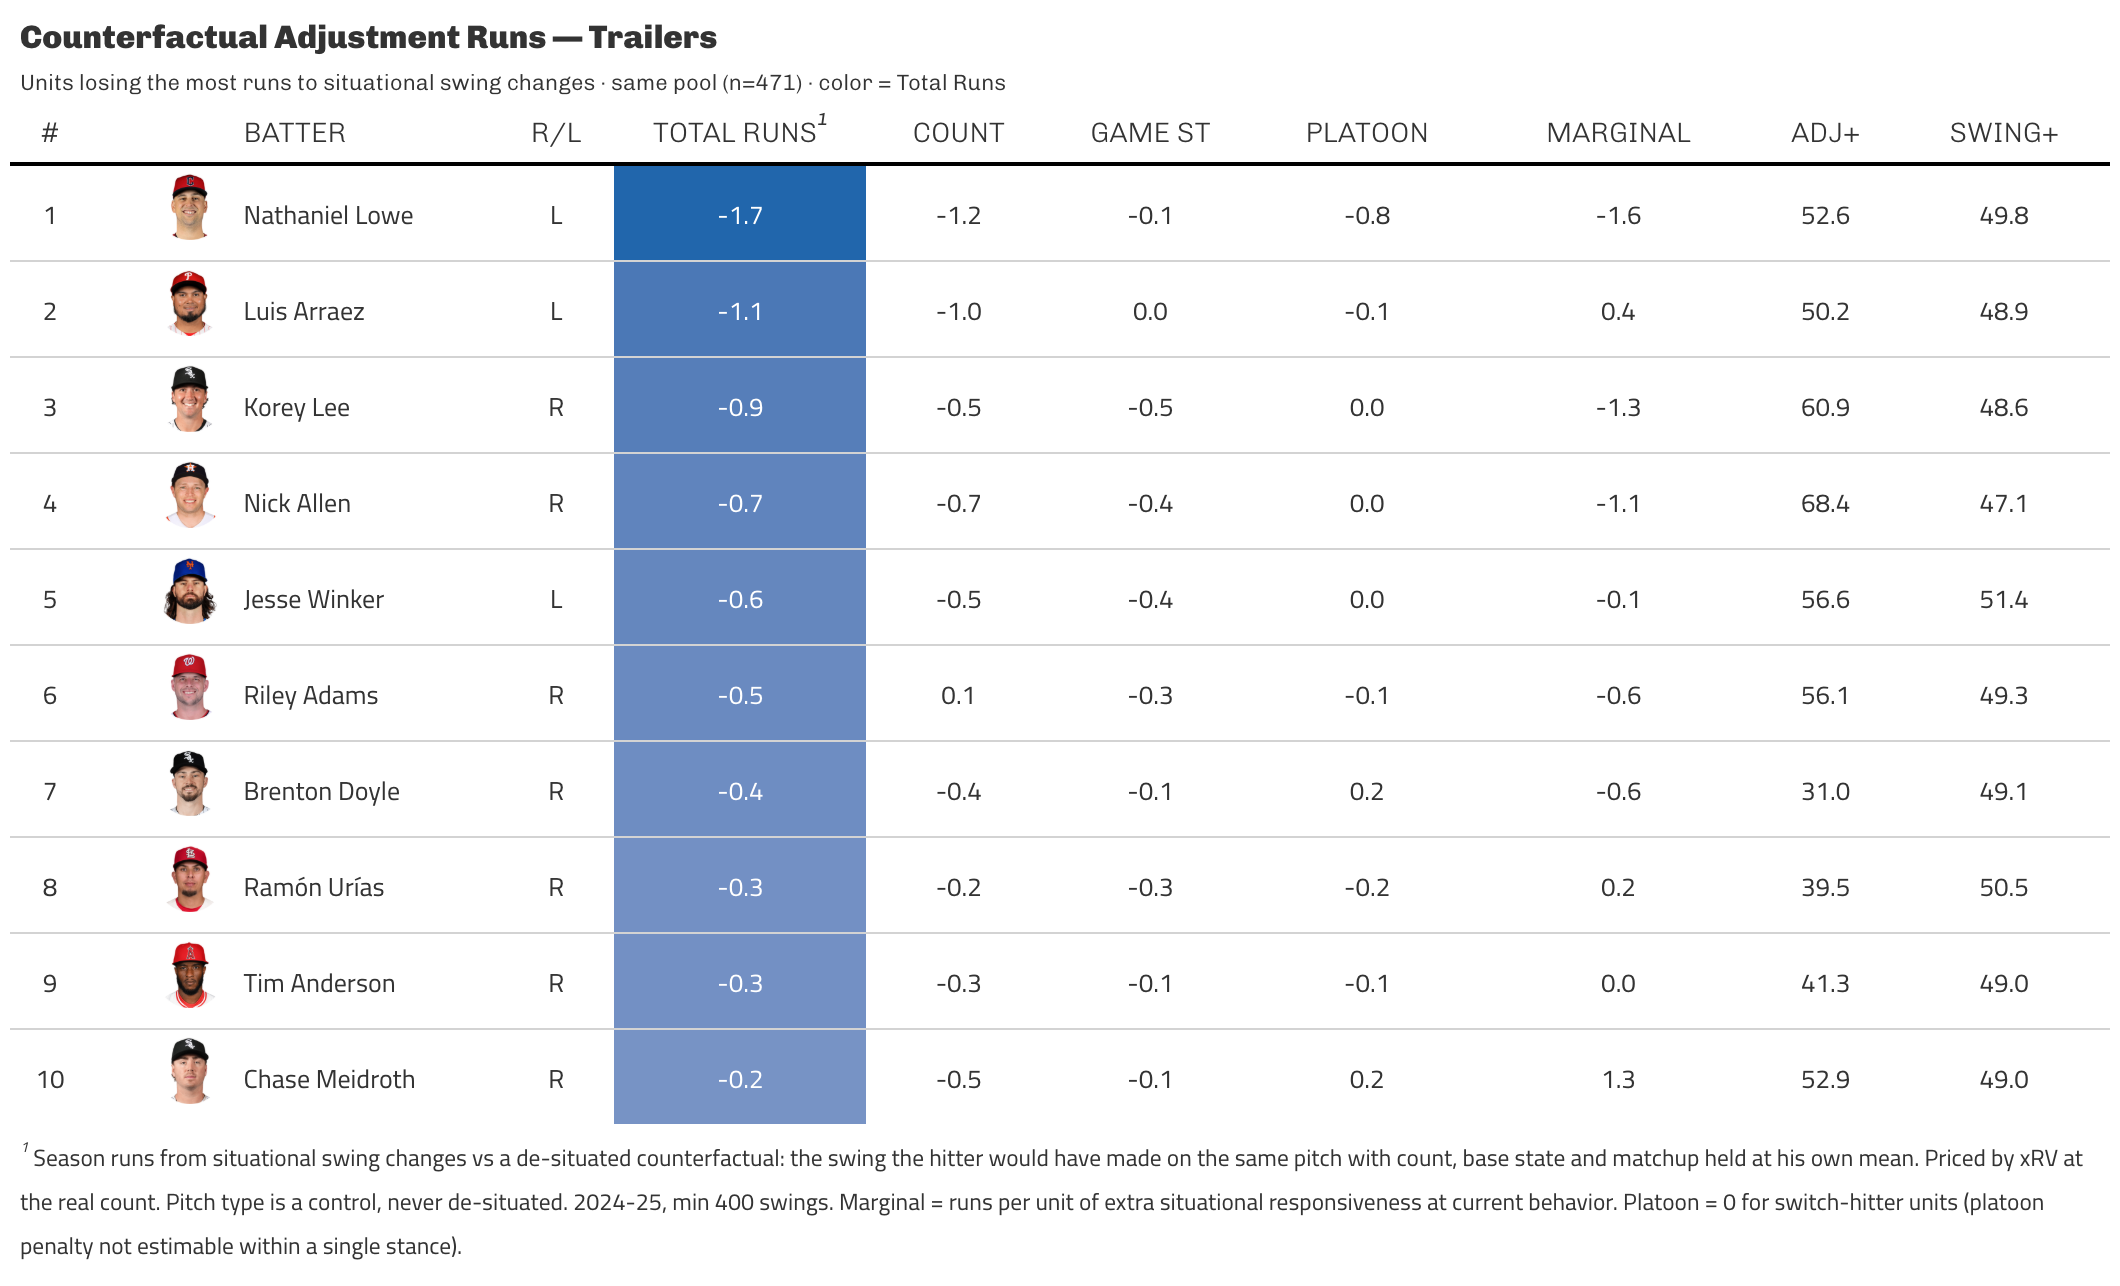

In [3]:
# Leaderboards rendered by src/leaderboard_table.R (gt + mlbplotR headshots).
from IPython.display import Image, display

for png in ['adj_policy_top_gt.png', 'adj_policy_bottom_gt.png']:
    p = plot_path(png)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print(f'Not yet generated: {png}')

## Axis decomposition

**Almost none of it is two-strike.** `runs_count` averages **+1.55** runs, but `runs_total_2k` — the
same per-swing deltas restricted to two-strike swings — averages **-0.03**. The count axis carries
the whole measure, and it earns its runs on 0- and 1-strike swings.

That qualifies the framing this project has been running on. `twostrike_rv_penalty` is the headline
penalty in `src/adjustability_value.py`, and the one significant payoff there
(`adj_count`, θ = +0.145, p = 0.0003) is a two-strike result. The counterfactual does not contradict
that coefficient — the two are different estimands, per-swing damage limitation inside matched cells
versus season-level run accumulation across all swings — but it does say the two-strike swing is not
where the season runs come from. The motivating two-strike story should be stated more narrowly than
it has been.

The other axes are near zero: game state -0.03, platoon +0.05. The interaction residual
(`runs_total` minus the three single-axis terms) averages +0.01, so the axes are close to additive
and the decomposition is not hiding value in cross-terms.

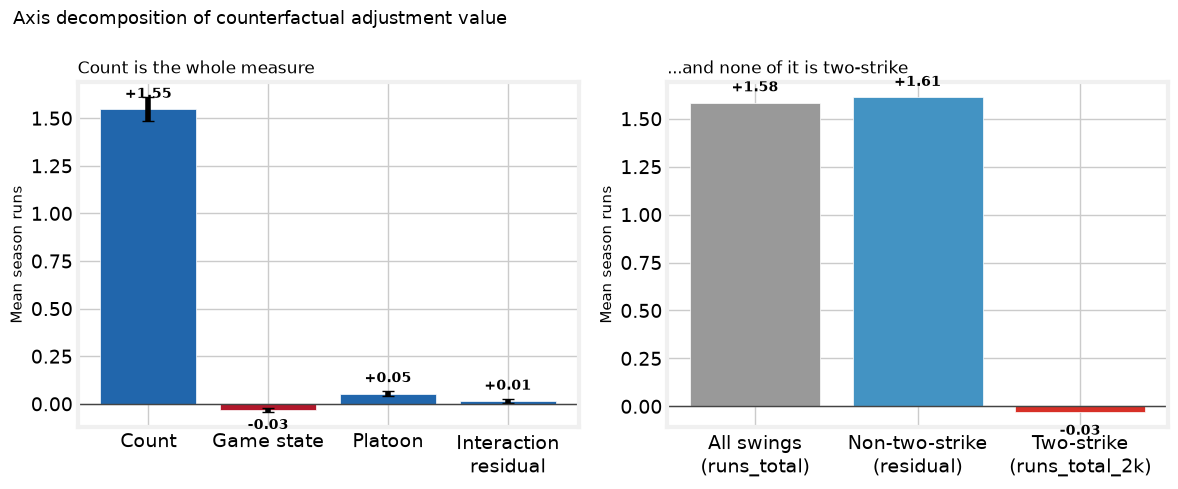

runs_count          1.547
runs_gamestate     -0.032
runs_platoon        0.054
runs_interaction    0.014
runs_total_2k      -0.028

non-two-strike share of runs_total: 101.8%


In [4]:
# Left: the axis decomposition. Right: the same count axis split into its two-strike and
# non-two-strike parts, which is where the two-strike framing breaks.
AX_COLS = ['runs_count', 'runs_gamestate', 'runs_platoon', 'runs_interaction']
AX_LABELS = ['Count', 'Game state', 'Platoon', 'Interaction\nresidual']
means = [df[c].mean() for c in AX_COLS]
ses = [df[c].std(ddof=1) / np.sqrt(len(df)) for c in AX_COLS]

two_k = df['runs_total_2k'].mean()
non_2k = df['runs_total'].mean() - two_k
split_vals = [df['runs_total'].mean(), non_2k, two_k]
split_labels = ['All swings\n(runs_total)', 'Non-two-strike\n(residual)', 'Two-strike\n(runs_total_2k)']
split_colors = ['#999999', '#4393c3', '#d73027']

with plt.style.context(FT):
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5))

    colors = ['#2166ac' if m > 0 else '#b2182b' for m in means]
    axL.bar(AX_LABELS, means, yerr=ses, color=colors, edgecolor='white', capsize=4)
    axL.axhline(0, color='#444', lw=1)
    for i, m in enumerate(means):
        axL.text(i, m + (0.06 if m >= 0 else -0.10), f'{m:+.2f}',
                 ha='center', fontsize=10, fontweight='bold')
    axL.set_ylabel('Mean season runs', fontsize=11)
    axL.set_title('Count is the whole measure', fontsize=12, loc='left')

    axR.bar(split_labels, split_vals, color=split_colors, edgecolor='white')
    axR.axhline(0, color='#444', lw=1)
    for i, v in enumerate(split_vals):
        axR.text(i, v + (0.06 if v >= 0 else -0.12), f'{v:+.2f}',
                 ha='center', fontsize=10, fontweight='bold')
    axR.set_ylabel('Mean season runs', fontsize=11)
    axR.set_title('...and none of it is two-strike', fontsize=12, loc='left')

    fig.suptitle('Axis decomposition of counterfactual adjustment value',
                 fontsize=13, x=0.02, ha='left')
    fig.tight_layout()
    plt.show()

print(df[AX_COLS + ['runs_total_2k']].mean().round(3).to_string())
print(f'\nnon-two-strike share of runs_total: {non_2k / df["runs_total"].mean():.1%}')

## Can we say how much to adjust?

**No — not from this grid. The prescriptive layer is unresolved. This is the finding, not a hedge,**
and the design spec pre-committed to reporting it as a first-class caveat rather than a footnote.

The build scans a blend parameter α over [0, 2] in steps of 0.25, where α=0 is the de-situated swing,
α=1 is what the hitter actually does, and α=2 doubles his situational swing change. An α is admitted
only if fewer than 5% of (swing, feature) pairs in the blended shape fall outside the unit's own
observed 1st–99th percentile envelope — a guard meant to stop xRV pricing shapes nobody has made.

That guard almost never binds. **88.5% of units land on a boundary of the admissible grid, and 406 of
471 peg at the maximum α=2.0**, so the median `alpha_star_supported` of 2.00 says where the grid
stops, not what a hitter should do. The mechanism is a scale mismatch. The envelope is built from
OBSERVED per-swing shape percentiles, which span the hitter's full empirical spread (per-feature SD
on the order of [5.6, 0.8, 5.1, 9.5, 18.0]), while the shapes being blended are FITTED values whose
situational component is far narrower (on the order of [0.7, 0.2, 1.8, 1.6, 2.3]). Doubling a small
fitted displacement inside a wide empirical envelope rarely leaves it, so the constraint has almost
nothing to reject and the argmax just runs to the edge.

**Do not read `alpha_star_supported` as a recommendation.** The only prescriptive quantity that
survives is `marginal_runs_per_alpha` — the local slope at current behaviour, a centred difference
between α=0.9 and α=1.1. It says which direction value moves and how steeply, at the swing the
hitter is already making. Its mean is +1.69 runs per unit of α.

The two panels below are a diagnostic of that binding problem. They are not a policy.

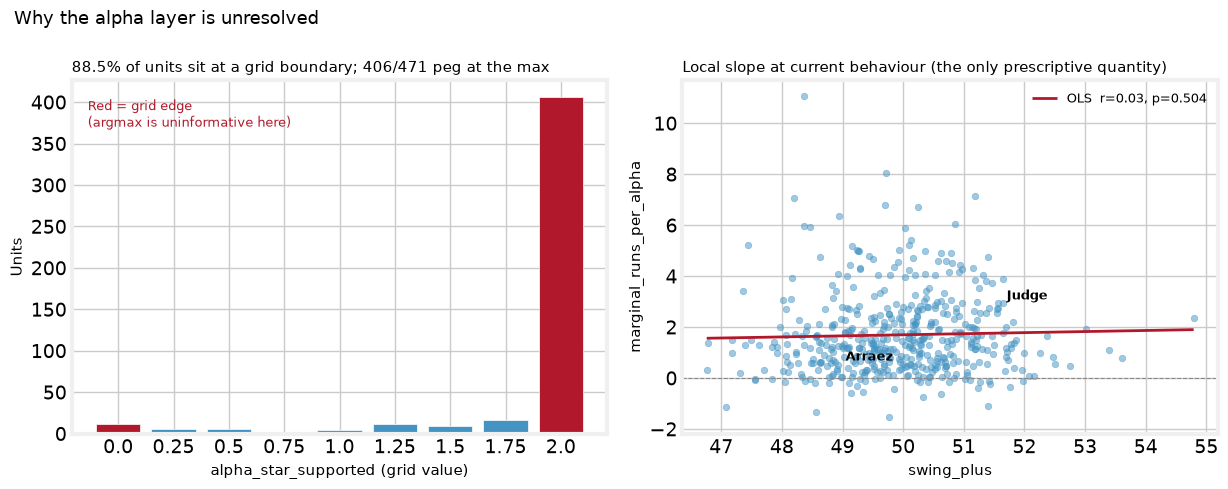

alpha_at_boundary: 88.5%   at grid max (2.0): 406/471
median alpha_star_supported: 2.00 (artifact of the grid ceiling, not a recommendation)
mean marginal_runs_per_alpha: +1.69 runs


In [5]:
# Diagnostic, not prescription: (A) alpha_star piles on the grid edge; (B) the local slope, the
# only quantity that survives, against how good the hitter's swing already is.
boundary_rate = df['alpha_at_boundary'].mean()
at_max = int((df['alpha_star_supported'] >= 2.0).sum())

with plt.style.context(FT):
    fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 5))

    grid = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
    counts = [int((df['alpha_star_supported'] == a).sum()) for a in grid]
    bar_colors = ['#b2182b' if a in (0.0, 2.0) else '#4393c3' for a in grid]
    axA.bar([str(a) for a in grid], counts, color=bar_colors, edgecolor='white')
    axA.set_xlabel('alpha_star_supported (grid value)', fontsize=11)
    axA.set_ylabel('Units', fontsize=11)
    axA.set_title(f'{boundary_rate:.1%} of units sit at a grid boundary; '
                  f'{at_max}/{len(df)} peg at the max',
                  fontsize=11, loc='left')
    axA.text(0.03, 0.95, 'Red = grid edge\n(argmax is uninformative here)',
             transform=axA.transAxes, ha='left', va='top', fontsize=9, color='#b2182b')

    axB.scatter(df['swing_plus'], df['marginal_runs_per_alpha'],
                color='#4393c3', alpha=0.5, s=22)
    m, b, r, p, _ = stats.linregress(df['swing_plus'], df['marginal_runs_per_alpha'])
    xs = np.linspace(df['swing_plus'].min(), df['swing_plus'].max(), 80)
    axB.plot(xs, m * xs + b, color='#b2182b', lw=2,
             label=f'OLS  r={r:.2f}, p={p:.3g}')
    axB.axhline(0, color='#888', lw=0.8, ls='--')
    for name, row in [('Judge', judge), ('Arraez', arraez)]:
        axB.annotate(name, xy=(row['swing_plus'], row['marginal_runs_per_alpha']),
                     xytext=(6, 6), textcoords='offset points', fontsize=9, fontweight='bold')
    axB.set_xlabel('swing_plus', fontsize=11)
    axB.set_ylabel('marginal_runs_per_alpha', fontsize=11)
    axB.set_title('Local slope at current behaviour (the only prescriptive quantity)',
                  fontsize=11, loc='left')
    axB.legend(frameon=False, fontsize=9)

    fig.suptitle('Why the alpha layer is unresolved', fontsize=13, x=0.02, ha='left')
    fig.tight_layout()
    fig.savefig(plot_path('adj_policy_alpha_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

print(f'alpha_at_boundary: {boundary_rate:.1%}   at grid max (2.0): {at_max}/{len(df)}')
print(f'median alpha_star_supported: {df["alpha_star_supported"].median():.2f} '
      f'(artifact of the grid ceiling, not a recommendation)')
print(f'mean marginal_runs_per_alpha: {df["marginal_runs_per_alpha"].mean():+.2f} runs')

## Who benefits?

Asked on the rate, `runs_per_swing`, not the counting total. The counting total is 62% correlated
with playing time, and "who benefits from adjusting" should not resolve to "whoever bats most".
Against mechanical adjustability the rate is also the stronger signal (r = +0.45 vs +0.30), so
stripping volume sharpens the relationship rather than washing it out.

Level Center    n=178  r=+0.522  p=0.0000  mean runs_per_swing=0.00247
Level Oppo      n=242  r=+0.373  p=0.0000  mean runs_per_swing=0.00234
Uppercut Pull   n= 51  r=+0.557  p=0.0000  mean runs_per_swing=0.00350


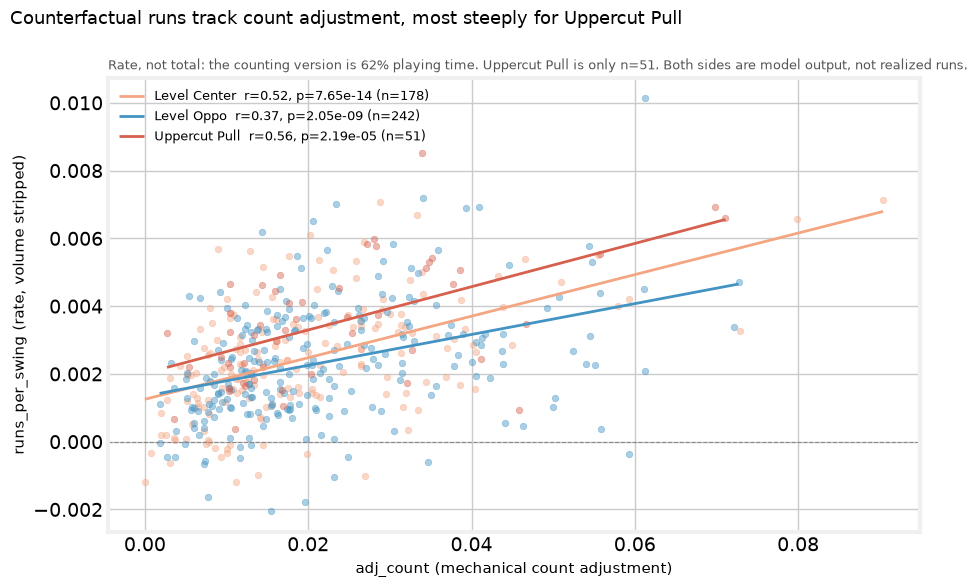


pooled: r=+0.446, p=2.28e-24, n=471


In [6]:
# Rate version on the y-axis on purpose: runs_count is a counting stat (corr with n_swings +0.62).
ARCH_COLORS = {'Level Oppo': '#4393c3', 'Level Center': '#f4a582', 'Uppercut Pull': '#d6604d'}

with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(9.5, 6))
    for arch, g in df.groupby('archetype_name'):
        c = ARCH_COLORS.get(arch, '#888')
        ax.scatter(g['adj_count'], g['runs_per_swing'], color=c, alpha=0.45, s=22, label=None)
        m, b, r, p, _ = stats.linregress(g['adj_count'], g['runs_per_swing'])
        xs = np.linspace(g['adj_count'].min(), g['adj_count'].max(), 80)
        ax.plot(xs, m * xs + b, color=c, lw=2,
                label=f'{arch}  r={r:.2f}, p={p:.3g} (n={len(g)})')
        print(f'{arch:<15} n={len(g):>3}  r={r:+.3f}  p={p:.4f}  '
              f'mean runs_per_swing={g["runs_per_swing"].mean():.5f}')
    ax.axhline(0, color='#888', lw=0.8, ls='--')
    ax.set_xlabel('adj_count (mechanical count adjustment)', fontsize=11)
    ax.set_ylabel('runs_per_swing (rate, volume stripped)', fontsize=11)
    ax.set_title('Rate, not total: the counting version is 62% playing time. '
                 'Uppercut Pull is only n=51. Both sides are model output, not realized runs.',
                 fontsize=9, color='#555', loc='left')
    fig.suptitle('Counterfactual runs track count adjustment, most steeply for Uppercut Pull',
                 fontsize=13, x=0.02, ha='left')
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    fig.savefig(plot_path('adj_policy_hte_archetype.png'), dpi=150, bbox_inches='tight')
    plt.show()

r_all, p_all = stats.pearsonr(df['adj_count'], df['runs_per_swing'])
print(f'\npooled: r={r_all:+.3f}, p={p_all:.3g}, n={len(df)}')

## Case studies

Judge and Arraez sit at opposite poles, and the ordering runs against the intuition this analysis
started from. Judge — the power profile you would expect to have the least room to fine-tune — gains
**+3.95** runs. Arraez, the contact hitter, is at **-1.09**, despite carrying the *higher* `adj_count`
(0.027 vs 0.017). More mechanical adjustment, less run value.

The archetype split points the same direction. Net of `n_swings`, Uppercut Pull units average about
**+0.67 runs** above Level Center, while Level Oppo is indistinguishable from it (about -0.04). On
the rate: 0.0035 runs/swing for Uppercut Pull against 0.0025 (Level Center) and 0.0023 (Level Oppo).
So the gap is not a playing-time artifact — it survives the volume control.

Two cautions, and they matter. Uppercut Pull is **n=51 of 471**, so the gap rests on a small subgroup.
And the obvious explanation — that adjustment is worth most to high-power, high-strikeout hitters who
have the most strikeout risk to mitigate — is **a conjecture this data cannot test**.
`optimal_policy.parquet` carries no strikeout-rate and no power column; nothing here measures
strikeout risk. What is established is the archetype gap and that it is not volume. The mechanism is
open, and testing it needs an outcome join this table does not have.

In [7]:
# Case profiles, then the archetype gap with an explicit volume control so the claim above is
# computed rather than asserted.
case_cols = ['label', 'batter_stand', 'archetype_name', 'runs_total', 'runs_count',
             'runs_total_2k', 'runs_per_swing', 'alpha_star_supported',
             'marginal_runs_per_alpha', 'swing_plus', 'adj_count', 'primary_grade', 'n_swings']
case = df[df['label'].isin(['Aaron Judge', 'Luis Arraez'])][case_cols]
print(case.set_index('label').T.to_string(float_format=lambda x: f'{x:.4f}'))

print('\n--- archetype means (raw) ---')
print(df.groupby('archetype_name')[['runs_total', 'runs_per_swing', 'n_swings']]
      .agg(['mean', 'size']).round(5).to_string())

print('\n--- runs_total ~ archetype + n_swings (Level Center is the reference) ---')
D = pd.get_dummies(df['archetype_name']).astype(float).drop(columns=['Level Center'])
D['n_swings'] = df['n_swings'].to_numpy(float)
D['const'] = 1.0
coefs, *_ = np.linalg.lstsq(D.to_numpy(float), df['runs_total'].to_numpy(float), rcond=None)
for name, c in zip(D.columns, coefs):
    print(f'  {name:<15} {c:+.4f}')
print('  (strikeout-risk mechanism is NOT tested here: no K-rate or power column in this table)')

label                      Aaron Judge   Luis Arraez
batter_stand                         R             L
archetype_name           Uppercut Pull  Level Center
runs_total                      3.9491       -1.0921
runs_count                      3.7148       -0.9769
runs_total_2k                   0.4880        0.0250
runs_per_swing                  0.0033       -0.0010
alpha_star_supported            2.0000        2.0000
marginal_runs_per_alpha         2.7533        0.3582
swing_plus                     51.5702       48.9128
adj_count                       0.0171        0.0269
primary_grade                  52.9000       49.4000
n_swings                          2401          2177

--- archetype means (raw) ---
               runs_total      runs_per_swing         n_swings     
                     mean size           mean size        mean size
archetype_name                                                     
Level Center      1.66619  178        0.00247  178  1305.72472  178
Level Op

## Validation

Full detail in `results/optimal_policy.md`. The verdict there, current as of this run:

> **Qualified.** The placebo collapses (ratio 0.11), so `runs_total` is not manufactured from noise.
> External support is thinner than that sounds. The predictive test is significant on `rv_per_swing`
> and null on `woba_swing`. `rv_per_swing` is realized `delta_run_exp` — close to what xRV is trained
> to reproduce, so it is the more circular of the two — while `woba_swing`, the less circular outcome,
> is null. The one fully disjoint outcome-side convergent test, `runs_count` against
> `twostrike_rv_penalty`, is r = 0.003. Read `runs_total` as an accounting decomposition with internal
> validity, not as a validated predictor of run production.

Supporting numbers: split-half reliability r = **0.560** across the 382 units with ≥150 swings in both
seasons, against `adjustability`'s year-over-year r = 0.67. The placebo shuffles situation labels
within unit, preserving marginals; mean |runs_total| falls from 2.11 to 0.23 (ratio 0.11, pass
threshold 0.3).

The tables below are parsed live from the report so this section cannot drift from it.

In [8]:
# Parse the convergent and predictive tables straight out of results/optimal_policy.md so the
# notebook cannot go stale against the report.
report = (ROOT / 'results' / 'optimal_policy.md').read_text()


def md_table(text, heading):
    """Return the first pipe table under a '## heading' as a DataFrame."""
    block = text.split(f'## {heading}', 1)[1].split('\n## ', 1)[0]
    rows = [ln for ln in block.splitlines() if ln.strip().startswith('|')]
    cells = [[c.strip() for c in ln.strip().strip('|').split('|')] for ln in rows]
    header, body = cells[0], [r for r in cells[2:]]
    out = pd.DataFrame(body, columns=header)
    for col in out.columns:
        num = pd.to_numeric(out[col], errors='coerce')
        if num.notna().all():
            out[col] = num
    return out


for heading in ['Convergent validity', 'Predictive validity']:
    print(f'--- {heading} ---')
    print(md_table(report, heading).to_string(index=False))
    print()

for line in report.splitlines():
    if line.startswith('- ') and any(k in line for k in ('split-half', 'placebo', 'real', 'ratio')):
        print(line)

--- Convergent validity ---
         x                    y   n     r
runs_count twostrike_rv_penalty 471 0.003
runs_count            adj_count 471 0.298
runs_total        adjustability 471 0.100
runs_total           swing_plus 471 0.102

--- Predictive validity ---
     outcome   n  theta     se    t      p
  woba_swing 471 0.0234 0.0403 0.58 0.5617
rv_per_swing 471 0.0826 0.0405 2.04 0.0421

- split-half r = **0.560**
- mean |runs_total| real: 2.11
- mean |runs_total| placebo: 0.23
- ratio: 0.11 (collapse expected — under ~0.3 is a pass)


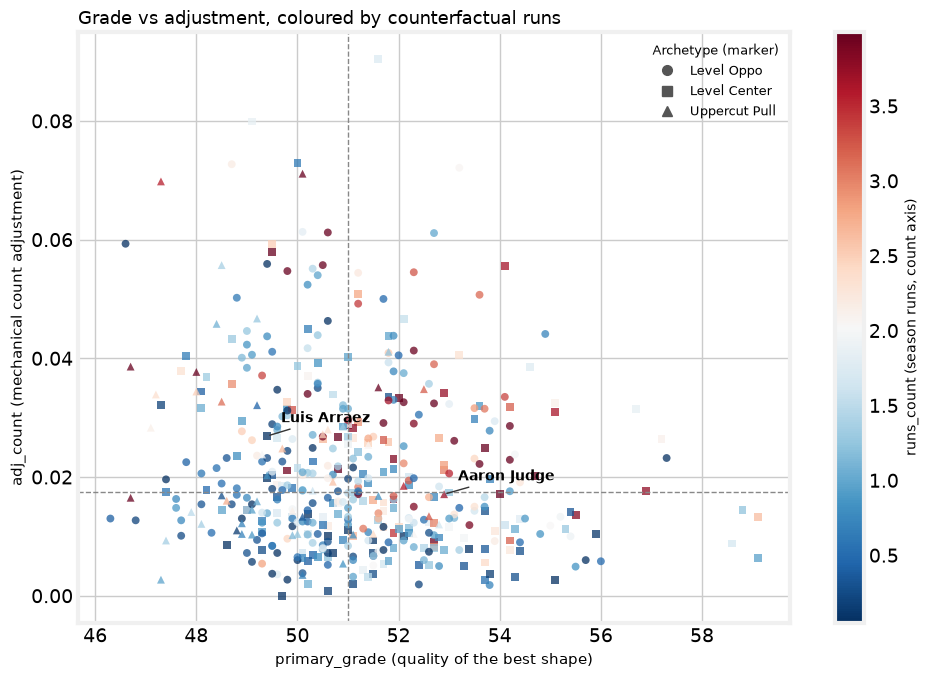

In [9]:
# The 2x2 framing: how good the hitter's best shape already is (x) against how much he moves it (y),
# coloured by season runs earned. Counting stat here on purpose -- this panel is the season-value view.
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

ARCH_MARKERS = {'Level Oppo': 'o', 'Level Center': 's', 'Uppercut Pull': '^'}
vmin, vmax = df['runs_count'].quantile(0.05), df['runs_count'].quantile(0.95)
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('RdBu_r')

with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(10, 7))
    for arch, g in df.groupby('archetype_name'):
        ax.scatter(g['primary_grade'], g['adj_count'],
                   c=[cmap(norm(v)) for v in g['runs_count']],
                   marker=ARCH_MARKERS.get(arch, 'o'), s=32, alpha=0.75,
                   edgecolors='none')

    ax.axvline(df['primary_grade'].median(), color='#888', lw=1, ls='--')
    ax.axhline(df['adj_count'].median(), color='#888', lw=1, ls='--')

    for name, row in [('Aaron Judge', judge), ('Luis Arraez', arraez)]:
        ax.annotate(name, xy=(row['primary_grade'], row['adj_count']),
                    xytext=(10, 10), textcoords='offset points', fontsize=10,
                    fontweight='bold',
                    arrowprops=dict(arrowstyle='-', color='#333', lw=1))

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax)
    cb.set_label('runs_count (season runs, count axis)', fontsize=10)

    ax.set_xlabel('primary_grade (quality of the best shape)', fontsize=11)
    ax.set_ylabel('adj_count (mechanical count adjustment)', fontsize=11)
    ax.set_title('Grade vs adjustment, coloured by counterfactual runs',
                 fontsize=13, loc='left')
    handles = [Line2D([], [], marker=m, ls='none', color='#555', markersize=7, label=a)
               for a, m in ARCH_MARKERS.items()]
    leg = ax.legend(handles=handles, frameon=False, fontsize=9, title='Archetype (marker)')
    leg.get_title().set_fontsize(9)
    fig.tight_layout()
    fig.savefig(plot_path('adj_policy_quadrant.png'), dpi=150, bbox_inches='tight')
    plt.show()